In [11]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score

In [12]:
split = "train"
filepath = f'split/p8_{split}.tsv'

if os.path.exists(filepath):
    df = pd.read_csv(filepath, sep='\t', encoding='latin-1')
else:
    # 파일이 없으면 다운로드 (in Colab)
    print('Downloading data from GitHub...')
    url = f"https://github.com/ssuai/asap/raw/refs/heads/main/{filepath}"
    df = pd.read_csv(url, sep='\t', encoding='latin-1')

df.head()

,essay_id,essay_set,essay,rater1_domain1,rater2_domain1,rater3_domain1,domain1_score,rater1_domain2,rater2_domain2,domain2_score,...,rater2_trait3,rater2_trait4,rater2_trait5,rater2_trait6,rater3_trait1,rater3_trait2,rater3_trait3,rater3_trait4,rater3_trait5,rater3_trait6
0,20716,8,A long time ago when I was in third grade I h...,18,16,NaN,34,NaN,NaN,NaN,...,4,4,3,3,NaN,NaN,NaN,NaN,NaN,NaN
1,20717,8,Softball has to be one of the single most gre...,21,26,46.0,46,NaN,NaN,NaN,...,6,6,5,5,5.0,5.0,5.0,5.0,5.0,4.0
2,20718,8,"Some people like making people laugh, I love ...",15,20,40.0,40,NaN,NaN,NaN,...,5,4,4,4,4.0,4.0,4.0,4.0,4.0,4.0
3,20721,8,Well ima tell a story about the time i got @CA...,11,15,NaN,26,NaN,NaN,NaN,...,3,3,3,3,NaN,NaN,NaN,NaN,NaN,NaN
4,20722,8,@CAPS3 I'm going to tell @CAPS18 a little stor...,20,18,40.0,40,NaN,NaN,NaN,...,5,4,4,3,4.0,4.0,4.0,4.0,4.0,4.0


## Trait 정의

Essay Set #8은 composite score가 아니라 **6개 writing trait(각 1–6점)** 으로 채점됩니다.

| trait # | 이름 | 약어 |
| --- | --- | --- |
| 1 | Ideas and Content | I |
| 2 | Organization | O |
| 3 | Voice | V |
| 4 | Word Choice | W |
| 5 | Sentence Fluency | S |
| 6 | Conventions | C |

Rater 1·2는 모든 essay에 대해 trait 점수를 부여하고, Rater 3는 non-adjacency / cusp rule에 의해 resolution이 필요할 때만 채점합니다. 세 평가자 모두 **동일한 1–6 척도**를 사용합니다.

In [13]:
TRAIT_NAMES = {
    1: 'Ideas and Content',
    2: 'Organization',
    3: 'Voice',
    4: 'Word Choice',
    5: 'Sentence Fluency',
    6: 'Conventions',
}

trait_ids = list(TRAIT_NAMES.keys())

def trait_cols(trait_id):
    return [
        f'rater1_trait{trait_id}',
        f'rater2_trait{trait_id}',
        f'rater3_trait{trait_id}',
    ]

all_trait_cols = [c for tid in trait_ids for c in trait_cols(tid)]
print(f"N essays: {len(df)}")
print(f"N with Rater 3: {df['rater3_trait1'].notna().sum()}")
print("\nMissing counts:")
display(df[all_trait_cols].isna().sum().to_frame('n_missing'))

N essays: 434
N with Rater 3: 78

Missing counts:


,n_missing
rater1_trait1,0
rater2_trait1,0
rater3_trait1,356
rater1_trait2,0
rater2_trait2,0
rater3_trait2,356
rater1_trait3,0
rater2_trait3,0
rater3_trait3,356
rater1_trait4,0


### Trait별 기술통계 및 분포

In [14]:
for tid, name in TRAIT_NAMES.items():
    cols = trait_cols(tid)
    print(f"\n=== Trait {tid}: {name} ===")
    display(df[cols].describe())


=== Trait 1: Ideas and Content ===


,rater1_trait1,rater2_trait1,rater3_trait1
count,434.000000,434.000000,78.000000
mean,3.737327,3.817972,3.923077
std,0.709642,0.720245,0.659973
min,1.000000,1.000000,2.000000
25%,3.000000,3.000000,4.000000
50%,4.000000,4.000000,4.000000
75%,4.000000,4.000000,4.000000
max,6.000000,6.000000,6.000000



=== Trait 2: Organization ===


,rater1_trait2,rater2_trait2,rater3_trait2
count,434.000000,434.000000,78.000000
mean,3.695853,3.776498,3.884615
std,0.689500,0.701895,0.623788
min,2.000000,1.000000,2.000000
25%,3.000000,3.000000,4.000000
50%,4.000000,4.000000,4.000000
75%,4.000000,4.000000,4.000000
max,6.000000,6.000000,6.000000



=== Trait 3: Voice ===


...

,rater1_trait4,rater2_trait4,rater3_trait4
count,434.000000,434.000000,78.000000
mean,3.834101,3.898618,3.987179
std,0.644850,0.625736,0.496575
min,2.000000,1.000000,3.000000
25%,4.000000,4.000000,4.000000
50%,4.000000,4.000000,4.000000
75%,4.000000,4.000000,4.000000
max,6.000000,6.000000,6.000000



=== Trait 5: Sentence Fluency ===


,rater1_trait5,rater2_trait5,rater3_trait5
count,434.00000,434.000000,78.000000
mean,3.71659,3.781106,3.858974
std,0.70652,0.696751,0.502574
min,2.00000,1.000000,2.000000
25%,3.00000,3.000000,4.000000
50%,4.00000,4.000000,4.000000
75%,4.00000,4.000000,4.000000
max,6.00000,6.000000,5.000000



=== Trait 6: Conventions ===


,rater1_trait6,rater2_trait6,rater3_trait6
count,434.000000,434.000000,78.000000
mean,3.555300,3.603687,3.628205
std,0.695038,0.702740,0.605365
min,2.000000,1.000000,2.000000
25%,3.000000,3.000000,3.000000
50%,4.000000,4.000000,4.000000
75%,4.000000,4.000000,4.000000
max,6.000000,6.000000,5.000000


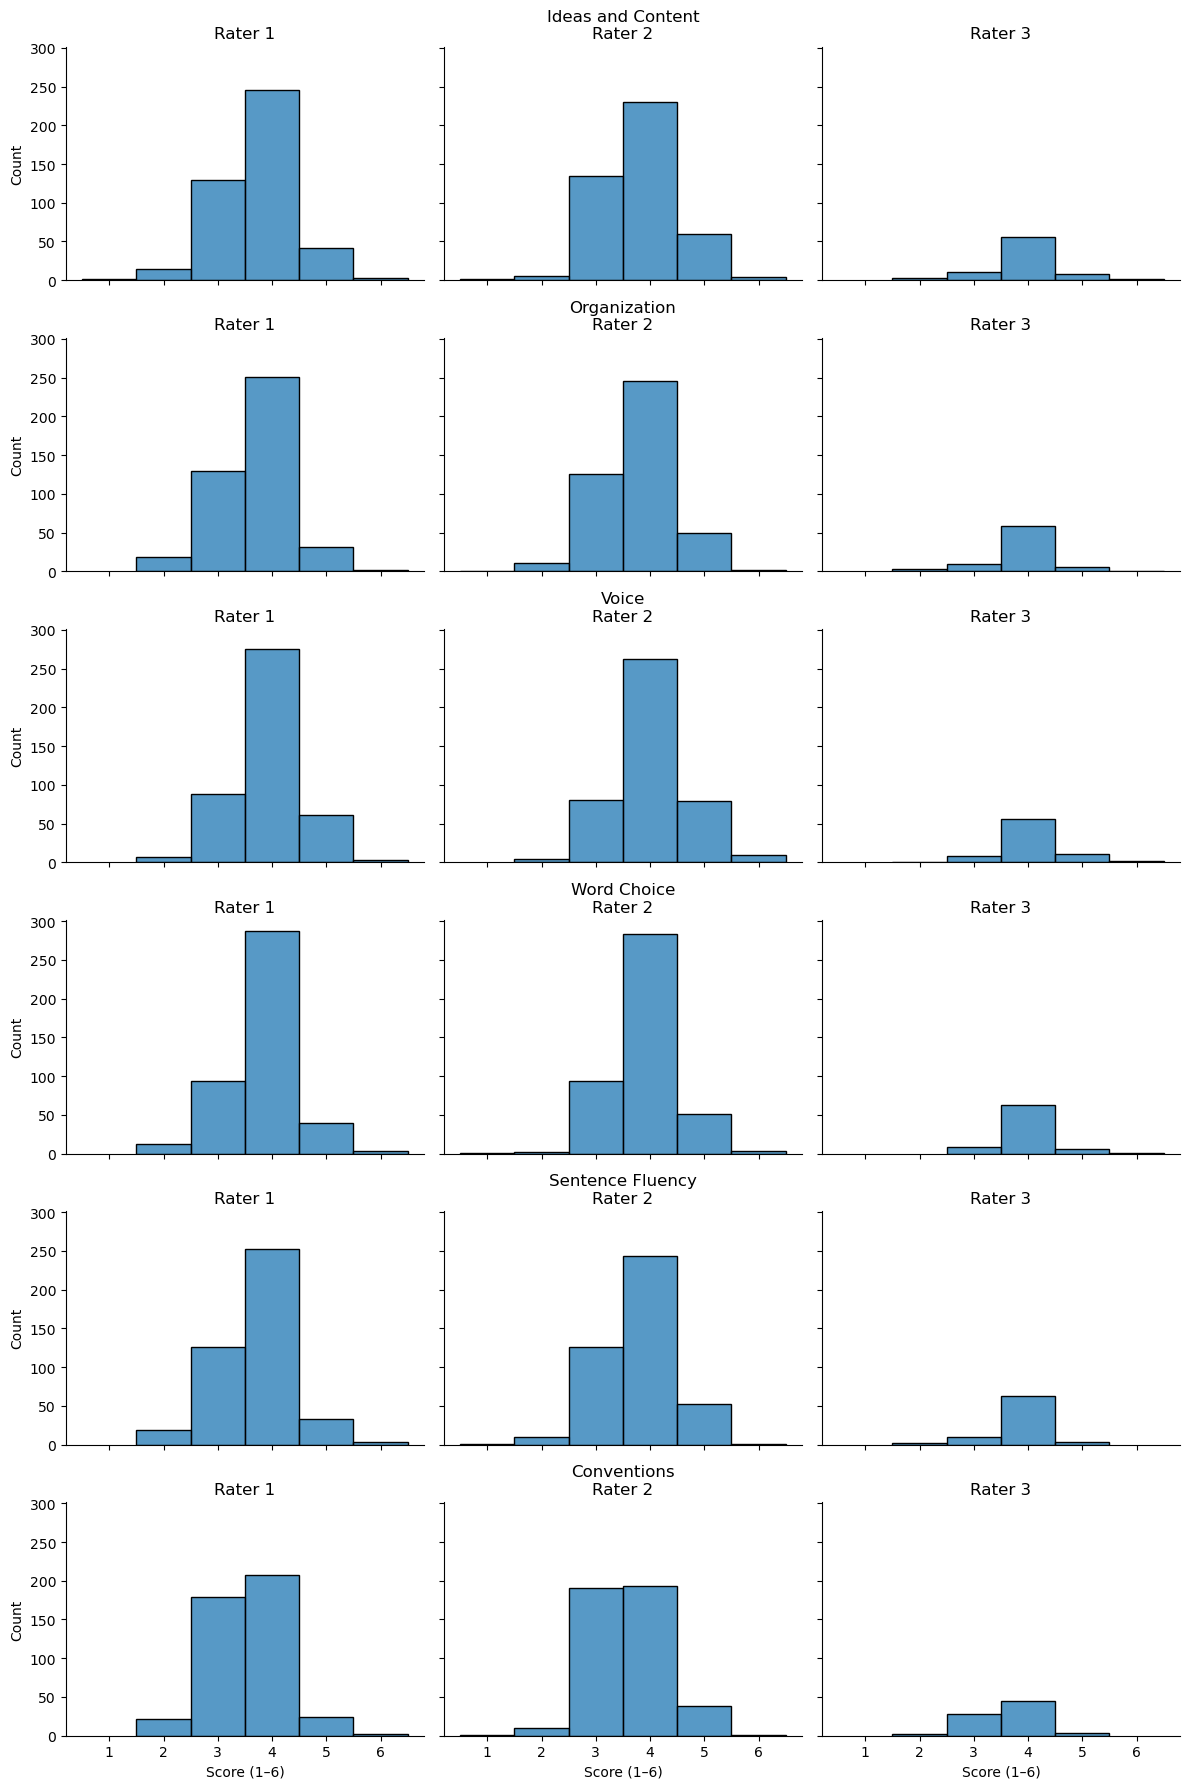

In [15]:
fig, axes = plt.subplots(6, 3, figsize=(12, 18), sharex=True, sharey=True)
rater_labels = ['Rater 1', 'Rater 2', 'Rater 3']

for row, (tid, name) in enumerate(TRAIT_NAMES.items()):
    for col, (rater_col, label) in enumerate(zip(trait_cols(tid), rater_labels)):
        ax = axes[row, col]
        sns.histplot(df[rater_col].dropna(), bins=np.arange(0.5, 7.5, 1), ax=ax, discrete=True)
        ax.set_title(f'{name}\n{label}' if col == 1 else label)
        ax.set_xlabel('Score (1–6)' if row == 5 else '')
        ax.set_ylabel('Count' if col == 0 else '')
        ax.set_xticks(range(1, 7))
        sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### Trait별 Pearson 상관 (Rater 1 vs Rater 2)

기본 채점은 Rater 1·2의 독립 채점이므로, 전체 essay에 대해 trait별 상관계수를 계산합니다. Rater 3가 있는 하위표본에서는 Rater 1–3, Rater 2–3 상관도 함께 봅니다.

,trait,"r(R1,R2)","n(R1,R2)","r(R1,R3)","n(R1,R3)","r(R2,R3)","n(R2,R3)"
0,1. Ideas and Content,0.5207,434,0.7683,78,0.5080,78
1,2. Organization,0.5178,434,0.6130,78,0.5285,78
2,3. Voice,0.4479,434,0.6043,78,0.4795,78
3,4. Word Choice,0.4791,434,0.6811,78,0.4057,78
4,5. Sentence Fluency,0.5117,434,0.5896,78,0.4983,78
5,6. Conventions,0.5225,434,0.4496,78,0.6328,78


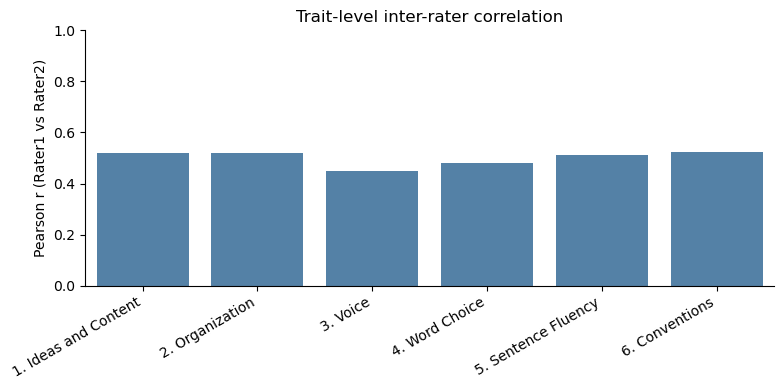

In [16]:
corr_rows = []
for tid, name in TRAIT_NAMES.items():
    c1, c2, c3 = trait_cols(tid)
    pair12 = df[[c1, c2]].dropna()
    pair13 = df[[c1, c3]].dropna()
    pair23 = df[[c2, c3]].dropna()
    corr_rows.append({
        'trait': f'{tid}. {name}',
        'r(R1,R2)': pair12[c1].corr(pair12[c2]),
        'n(R1,R2)': len(pair12),
        'r(R1,R3)': pair13[c1].corr(pair13[c3]) if len(pair13) else np.nan,
        'n(R1,R3)': len(pair13),
        'r(R2,R3)': pair23[c2].corr(pair23[c3]) if len(pair23) else np.nan,
        'n(R2,R3)': len(pair23),
    })

corr_df = pd.DataFrame(corr_rows)
display(corr_df.round(4))

plt.figure(figsize=(8, 4))
sns.barplot(data=corr_df, x='trait', y='r(R1,R2)', color='steelblue')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Pearson r (Rater1 vs Rater2)')
plt.xlabel('')
plt.ylim(0, 1)
plt.title('Trait-level inter-rater correlation')
sns.despine()
plt.tight_layout()
plt.show()

### Exact / Adjacent 일치율

루브릭 adjudication rule은 **non-adjacency**(두 평가자 점수 차이가 2점 이상)일 때 resolution을 요구합니다. 따라서 trait별로

- **Exact agreement**: `|R1 − R2| = 0`
- **Adjacent agreement**: `|R1 − R2| ≤ 1`

비율을 확인합니다.

,trait,n,exact_%,adjacent_%,non_adjacent_%,mean_|diff|
0,1. Ideas and Content,434,57.37,97.70,2.30,0.45
1,2. Organization,434,61.06,97.24,2.76,0.42
2,3. Voice,434,58.53,97.00,3.00,0.45
3,4. Word Choice,434,65.21,97.47,2.53,0.37
4,5. Sentence Fluency,434,58.99,97.93,2.07,0.43
5,6. Conventions,434,56.68,98.85,1.15,0.44


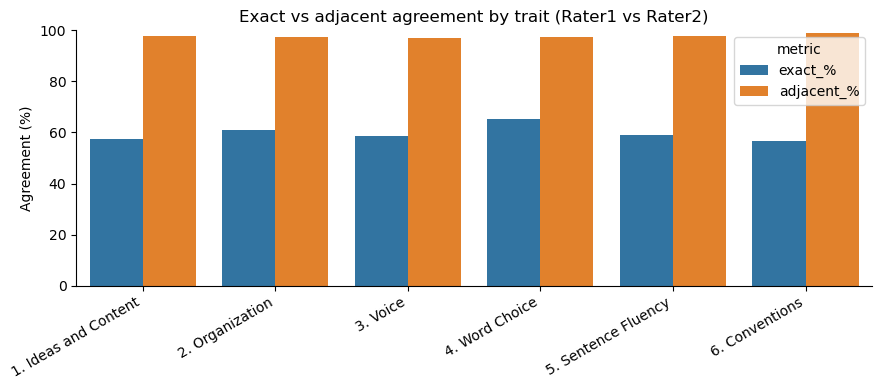

In [17]:
agree_rows = []
for tid, name in TRAIT_NAMES.items():
    c1, c2, _ = trait_cols(tid)
    pair = df[[c1, c2]].dropna()
    diff = (pair[c1] - pair[c2]).abs()
    agree_rows.append({
        'trait': f'{tid}. {name}',
        'n': len(pair),
        'exact_%': 100 * (diff == 0).mean(),
        'adjacent_%': 100 * (diff <= 1).mean(),
        'non_adjacent_%': 100 * (diff >= 2).mean(),
        'mean_|diff|': diff.mean(),
    })

agree_df = pd.DataFrame(agree_rows)
display(agree_df.round(2))

plot_df = agree_df.melt(
    id_vars='trait',
    value_vars=['exact_%', 'adjacent_%'],
    var_name='metric',
    value_name='percent',
)
plt.figure(figsize=(9, 4))
sns.barplot(data=plot_df, x='trait', y='percent', hue='metric')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Agreement (%)')
plt.xlabel('')
plt.ylim(0, 100)
plt.title('Exact vs adjacent agreement by trait (Rater1 vs Rater2)')
sns.despine()
plt.tight_layout()
plt.show()

### Quadratic Weighted Kappa (QWK)

순서형(1–6) 루브릭 점수에 널리 쓰이는 일치도 지표입니다. 차이가 클수록 더 큰 페널티를 줍니다.

,trait,"QWK(R1,R2)","n(R1,R2)","QWK(R1,R3)","n(R1,R3)","QWK(R2,R3)","n(R2,R3)"
0,1. Ideas and Content,0.5174,434,0.7347,78,0.5078,78
1,2. Organization,0.5142,434,0.5899,78,0.5273,78
2,3. Voice,0.4420,434,0.5895,78,0.4656,78
3,4. Word Choice,0.4764,434,0.6296,78,0.3922,78
4,5. Sentence Fluency,0.5095,434,0.5359,78,0.4871,78
5,6. Conventions,0.5213,434,0.4462,78,0.6251,78


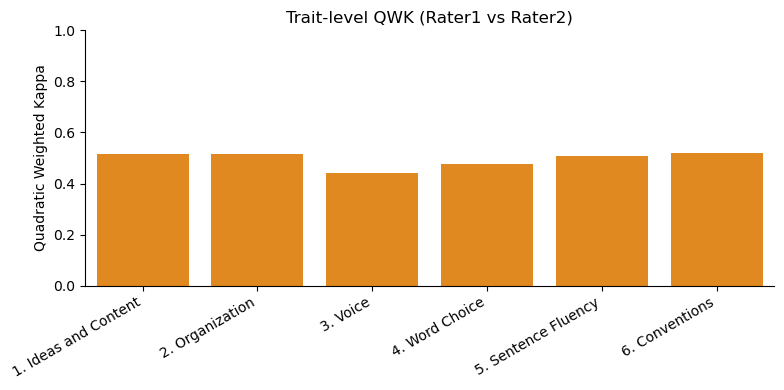

In [18]:
qwk_rows = []
for tid, name in TRAIT_NAMES.items():
    c1, c2, c3 = trait_cols(tid)
    pair12 = df[[c1, c2]].dropna()
    pair13 = df[[c1, c3]].dropna()
    pair23 = df[[c2, c3]].dropna()

    row = {
        'trait': f'{tid}. {name}',
        'QWK(R1,R2)': cohen_kappa_score(pair12[c1], pair12[c2], weights='quadratic'),
        'n(R1,R2)': len(pair12),
    }
    if len(pair13):
        row['QWK(R1,R3)'] = cohen_kappa_score(pair13[c1], pair13[c3], weights='quadratic')
        row['n(R1,R3)'] = len(pair13)
    if len(pair23):
        row['QWK(R2,R3)'] = cohen_kappa_score(pair23[c2], pair23[c3], weights='quadratic')
        row['n(R2,R3)'] = len(pair23)
    qwk_rows.append(row)

qwk_df = pd.DataFrame(qwk_rows)
display(qwk_df.round(4))

plt.figure(figsize=(8, 4))
sns.barplot(data=qwk_df, x='trait', y='QWK(R1,R2)', color='darkorange')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Quadratic Weighted Kappa')
plt.xlabel('')
plt.ylim(0, 1)
plt.title('Trait-level QWK (Rater1 vs Rater2)')
sns.despine()
plt.tight_layout()
plt.show()

### ICC (Rater 1·2)

`pingouin`으로 trait별 ICC를 계산합니다. Rater 3는 결측이 많으므로 **Rater 1·2**를 기준으로 합니다 (Two-way random, absolute agreement: `ICC(A,1)` / `ICC(A,k)`, 구버전 표기 `ICC2` / `ICC2k`).

필요 시 아래 셀에서 pingouin을 설치하세요.

In [19]:
# %pip install pingouin --quiet

Using labels: ICC(A,1) / ICC(A,k)


,trait,n,"ICC(A,1)","ICC(A,k)"
0,1. Ideas and Content,434,0.5180,0.6825
1,2. Organization,434,0.5148,0.6797
2,3. Voice,434,0.4426,0.6136
3,4. Word Choice,434,0.4770,0.6459
4,5. Sentence Fluency,434,0.5101,0.6756
5,6. Conventions,434,0.5218,0.6858


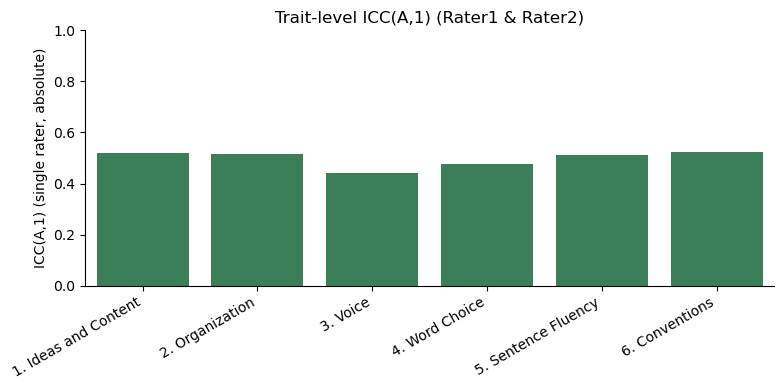

In [20]:
import pingouin as pg

def extract_icc(icc_table, single_aliases, average_aliases):
    """pingouin 버전별 Type 라벨 차이를 흡수 (구: ICC2/ICC2k, 신: ICC(A,1)/ICC(A,k))."""
    types = set(icc_table['Type'].astype(str))
    single = next((t for t in single_aliases if t in types), None)
    average = next((t for t in average_aliases if t in types), None)
    if single is None or average is None:
        raise KeyError(f'Expected ICC types not found. Available: {sorted(types)}')
    return (
        icc_table.loc[icc_table['Type'] == single, 'ICC'].iloc[0],
        icc_table.loc[icc_table['Type'] == average, 'ICC'].iloc[0],
        single,
        average,
    )

# absolute agreement, single / average raters
SINGLE_ALIASES = ['ICC(A,1)', 'ICC2']
AVERAGE_ALIASES = ['ICC(A,k)', 'ICC2k']

icc_rows = []
for tid, name in TRAIT_NAMES.items():
    c1, c2, _ = trait_cols(tid)
    wide = df[[c1, c2]].dropna().rename(columns={c1: 'rater1', c2: 'rater2'})
    long = wide.reset_index().melt(
        id_vars='index', var_name='rater', value_name='score'
    ).rename(columns={'index': 'essay_id'})

    icc = pg.intraclass_corr(
        data=long,
        targets='essay_id',
        raters='rater',
        ratings='score',
    )
    icc_single, icc_avg, single_label, avg_label = extract_icc(
        icc, SINGLE_ALIASES, AVERAGE_ALIASES
    )
    icc_rows.append({
        'trait': f'{tid}. {name}',
        'n': len(wide),
        'ICC(A,1)': icc_single,
        'ICC(A,k)': icc_avg,
    })

icc_df = pd.DataFrame(icc_rows)
print(f'Using labels: {single_label} / {avg_label}')
display(icc_df.round(4))

plt.figure(figsize=(8, 4))
sns.barplot(data=icc_df, x='trait', y='ICC(A,1)', color='seagreen')
plt.xticks(rotation=30, ha='right')
plt.ylabel('ICC(A,1) (single rater, absolute)')
plt.xlabel('')
plt.ylim(0, 1)
plt.title('Trait-level ICC(A,1) (Rater1 & Rater2)')
sns.despine()
plt.tight_layout()
plt.show()


### (선택) Rater 3 포함 ICC

세 평가자가 모두 채점한 essay만으로 trait별 ICC를 계산합니다. 표본이 resolution 케이스에 편향되어 있으므로 해석에 주의합니다.

In [21]:
icc3_rows = []
for tid, name in TRAIT_NAMES.items():
    cols = trait_cols(tid)
    wide = df[cols].dropna().rename(
        columns={cols[0]: 'rater1', cols[1]: 'rater2', cols[2]: 'rater3'}
    )
    long = wide.reset_index().melt(
        id_vars='index', var_name='rater', value_name='score'
    ).rename(columns={'index': 'essay_id'})

    icc = pg.intraclass_corr(
        data=long,
        targets='essay_id',
        raters='rater',
        ratings='score',
    )
    icc_single, icc_avg, _, _ = extract_icc(icc, SINGLE_ALIASES, AVERAGE_ALIASES)
    icc3_rows.append({
        'trait': f'{tid}. {name}',
        'n': len(wide),
        'ICC(A,1)': icc_single,
        'ICC(A,k)': icc_avg,
    })

icc3_df = pd.DataFrame(icc3_rows)
print('Complete cases with all 3 raters:')
display(icc3_df.round(4))


Complete cases with all 3 raters:


,trait,n,"ICC(A,1)","ICC(A,k)"
0,1. Ideas and Content,78,0.4629,0.7211
1,2. Organization,78,0.3919,0.6591
2,3. Voice,78,0.3393,0.6064
3,4. Word Choice,78,0.3388,0.6059
4,5. Sentence Fluency,78,0.3770,0.6448
5,6. Conventions,78,0.3832,0.6508


### 결과 요약

아래 테이블에 trait별 주요 일치도 지표를 모았습니다.

In [22]:
summary = (
    agree_df[['trait', 'exact_%', 'adjacent_%', 'non_adjacent_%']]
    .merge(corr_df[['trait', 'r(R1,R2)']], on='trait')
    .merge(qwk_df[['trait', 'QWK(R1,R2)']], on='trait')
    .merge(icc_df[['trait', 'ICC(A,1)', 'ICC(A,k)']], on='trait')
)
display(summary.round(4))

print('\n일치도가 가장 높은 trait (QWK 기준):', summary.loc[summary['QWK(R1,R2)'].idxmax(), 'trait'])
print('일치도가 가장 낮은 trait (QWK 기준):', summary.loc[summary['QWK(R1,R2)'].idxmin(), 'trait'])


,trait,exact_%,adjacent_%,non_adjacent_%,"r(R1,R2)","QWK(R1,R2)","ICC(A,1)","ICC(A,k)"
0,1. Ideas and Content,57.3733,97.6959,2.3041,0.5207,0.5174,0.5180,0.6825
1,2. Organization,61.0599,97.2350,2.7650,0.5178,0.5142,0.5148,0.6797
2,3. Voice,58.5253,97.0046,2.9954,0.4479,0.4420,0.4426,0.6136
3,4. Word Choice,65.2074,97.4654,2.5346,0.4791,0.4764,0.4770,0.6459
4,5. Sentence Fluency,58.9862,97.9263,2.0737,0.5117,0.5095,0.5101,0.6756
5,6. Conventions,56.6820,98.8479,1.1521,0.5225,0.5213,0.5218,0.6858



일치도가 가장 높은 trait (QWK 기준): 6. Conventions
일치도가 가장 낮은 trait (QWK 기준): 3. Voice


### 해석 가이드

- **Exact / Adjacent agreement**: 채점 실무에서 바로 읽히는 지표. Adjacent가 낮으면(non-adjacent가 높으면) 해당 trait에서 resolution이 자주 발생합니다.
- **QWK**: 순서형 채점의 표준 일치도. 보통 0.4–0.6 moderate, 0.6–0.8 substantial로 해석합니다.
- **ICC(A,1)**: 단일 평가자 절대 일치도(구버전 `ICC2`). **ICC(A,k)**는 평가자 평균을 쓸 때의 신뢰도(구버전 `ICC2k`)입니다.
- **Rater 3 포함 분석**: resolution이 필요한 어려운 케이스만 포함되므로, Rater 1·2 전체 표본보다 일치도가 낮게 나오는 것이 자연스럽습니다.
- Composite `domain1_score` 분석과 달리, 여기서는 trait마다 같은 1–6 척도이므로 척도 변환 없이 직접 비교할 수 있습니다.
